In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import ifft

## Koeffizienten finden
Die Formeln für die Umwandlung sind sehr kompliziert und werden in Theorie im Skript erklärt. Der folgende Code-Auszug stammt aus dem Skript und wertet genau diese Formeln aus:

In [7]:
def chebexp(y):
    # WICHTIG: gibt Koeffizienten für [-1, 1]
    n = y.shape[0] - 1

    t = np.arange(0, 2*n+2)
    z = np.exp(-np.pi * 1j * n/(n+1.0) * t) * np.hstack([y,y[::-1]])
    
    c = ifft(z)
    
    t = np.arange(-n, n+2)
    b = (np.exp(0.5j * np.pi/(n+1.0) * t) * c).real
    
    a = np.hstack([ b[n], 2 * b[n+1:2*n+1] ])
    return a

## Auswertung
Nun wenden wir den Clenshaw-Algorithmus an, der bereits in der zweiten Aufgabenserie zur Polynominterpolation vorkam: 

In [8]:
def clenshaw(a,x):
    n = len(a) - 1     # Messstellen
    N = len(x)         # Auswertungsstellen

    d = np.zeros((n+3, N))  # Rekursion über Zeilen einer Matrix
    
    for i in range(n,-1,-1):
      d[i] = a[i] + (2*x)*d[i+1] - d[i+2]
    
    y = d[0] - x*d[1]  # Lösung aus letzten zwei Zeilen
    return y

Die Idee des Clenshaw-Algorithmus ist, dass *d* eine rückwärts-rekursiv definierte Folge ist mit $d_{n+2}=d_{n+1}=0$, deren erste zwei Elemente ($d_0 - xd_1$) genau die Auswertung des Inteprolationspolynoms $\hat{p}(x)$ ergeben.

## Ausführung
Nun wenden wir diese Methoden auf eine Funktion $f$ an:

In [9]:
f = lambda x: 4*x**5 + 8*x**2

In [10]:
a, b = -2, 2
n, N = 10, 500

k = np.arange(n+1)
x = a + 0.5*(b-a)*(np.cos((2*k+1) / (2 * (n+1)) * np.pi) + 1)
X = np.linspace(a, b, N)
y = f(x)
Y = f(X)

Es ist wichtig anzumerken, dass die Koeffizienten von unserem `chebexp` davon ausgehen, dass unsere Werte an den Chebyshev-Knoten im Intervall $[-1, 1]$ gemessen wurden. Dementsprechend können wir bei clenshaw einfach Auswertungsstellen in $[-1,1]$ übergeben, und diese dann beim Plot als Stellen im Intervall $[a, b]$ darstellen.

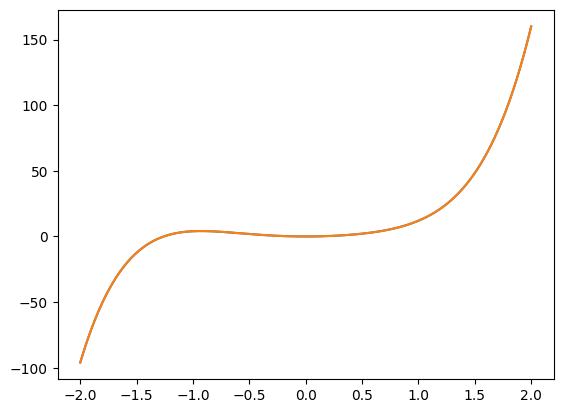

In [11]:
c = chebexp(y)
Z = clenshaw(c, np.linspace(-1, 1, N)) # Im entsprechenden Intervall auswerten

plt.plot(X, Y)
plt.plot(X, Z)